# Projet ML for Econometrics

## Introduction

Ce notebook retrace l'ensemble de notre travail effectué dans le cadre du projet pour le cours de ML for Econometrics présenté par Mr. Doutreligne et Mr. Crépon

## Présentation de la base de données et de la problématique

Nous nous appuyons sur le dataset "Predict Students' Dropout and Academic Success" qui est une base de données disponible publiquement via le lien suivant https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

Cette base de données répertorie le parcours scolaire de 4424 étudiants dans différents cursus (agronomie, design, infirmier, etc.). La BDD donne pour chaque individu de nombreuses informations socio-démographiques de l'élève (sexe, âge, niveau scolaire des deux parents, nationalité, etc.) ainsi que des données sur son parcours scolaire (note durant les deux semestres de l'année) ainsi que la situation de l'élève à la fin du temps scolaire.

Cette dernière variable est ici notre variable d'intérêt, elle peut prendre trois valeurs différentes : dropout si l'élève a abandonné les études, graduate si l'élève a été diplômé, ou enrolled si l'élève continue les cours dans un temps supplémentaire.

Notre travail se concentre sur la recherche de l'effet causal d'avoir une bourse d'études sur la réussite de l'élève.

## Formulation PICO de notre problématique

P : La population étudiée ici est un ensemble d'étudiants étant en études entre 2008 et 2018

I : L'intervention que l'on considère ici est le fait de recevoir une bourse durant ses études

C : On compare cela avec les étudiants n'ayant pas reçu de bourse durant leur études

O : L'outcome considéré est le fait d'obtenir son diplôme à la fin du parcours scolaire

## Introduction, analyse sociologique et DAG

## Analyse descriptive des données

L'objectif de cette seconde partie est de visualiser en détails la base de données, en particulier on s'attardera particulièrement sur l'outcome et sur les variables corrélées avec le fait d'avoir une bourse

### Téléchargement des données et nettoyage de la BDD

In [84]:
#pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 


In [85]:

print("--- 1. Chargement du dataset ---")
dataset = fetch_ucirepo(id=697) 
X = dataset.data.features 
y = dataset.data.targets 
X["Application mode"] = X["Application mode"].astype(str)
X["Course"] = X["Course"].astype(str)
X["Father\'s occupation"] = X["Father\'s occupation"].astype(str)
X["Mother\'s occupation"] = X["Mother\'s occupation"].astype(str)
X["Father\'s qualification"] = X["Father\'s qualification"].astype(str)
X["Mother\'s qualification"] = X["Mother\'s qualification"].astype(str)
X["Marital Status"] = X["Marital Status"].astype(str)
X["Nacionality"] = X["Nacionality"].astype(str)
X["Previous qualification"] = X["Previous qualification"].astype(str)
df = pd.concat([X, y], axis=1)

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")

print("--- 2. Types de variables et Valeurs manquantes ---")
valeurs_manquantes = pd.DataFrame({
    'Type': df.dtypes,
    'Manquants (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Valeurs Uniques': df.nunique()
})
print(valeurs_manquantes)

print("\n--- 3. Statistiques Descriptives ---")
display(df.describe().T.round(2))

--- 1. Chargement du dataset ---
Dimensions du dataset : 4424 lignes, 37 colonnes

--- 2. Types de variables et Valeurs manquantes ---
                                                   Type  Manquants (%)  \
Marital Status                                   object            0.0   
Application mode                                 object            0.0   
Application order                                 int64            0.0   
Course                                           object            0.0   
Daytime/evening attendance                        int64            0.0   
Previous qualification                           object            0.0   
Previous qualification (grade)                  float64            0.0   
Nacionality                                      object            0.0   
Mother's qualification                           object            0.0   
Father's qualification                           object            0.0   
Mother's occupation                              ob

/tmp/ipykernel_63787/280577157.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Application mode"] = X["Application mode"].astype(str)
/tmp/ipykernel_63787/280577157.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Course"] = X["Course"].astype(str)
/tmp/ipykernel_63787/280577157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

,count,mean,std,min,25%,50%,75%,max
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Displaced,4424.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Educational special needs,4424.0,0.01,0.11,0.00,0.00,0.00,0.00,1.00
Debtor,4424.0,0.11,0.32,0.00,0.00,0.00,0.00,1.00
Tuition fees up to date,4424.0,0.88,0.32,0.00,1.00,1.00,1.00,1.00
Gender,4424.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00
Scholarship holder,4424.0,0.25,0.43,0.00,0.00,0.00,0.00,1.00


Comme nous le montrent ces résultats, la base de données ne contient pas de valeur manquante.

Cependant, ce résultat cache d'une certaine façon la réalité : Rappelons que dans note BDD, certains élèves abandonnent leurs études au cours de l'année.
Ainsi, les variables inquant le nombre d'ECTS crédités par semestre ainsi que les notes des élèves n'a pas trop de signification : en effet, un élève qui abandonne son année aura administrativement des notes nulles pour le reste de l'année.

Comme l'idée de notre projet est d'étudier les facteurs qui influent en amont sur le fait d'avoir une bourse et de réussir son année, ces variables en question ne semblent pas pertinentes et risquent de nous induire en erreur. Ainsi, on les supprime du dataset

Notons également que certaines variables, comme le travail des parents ou la nationalité de l'élève, sont des variables nominales encodées en entier. Il est donc important de les transformer en string pour ne pas faire d'erreur par la suite.

In [86]:
df["Mother\'s occupation"].value_counts()

Mother's occupation
9      1577
4       817
5       530
3       351
2       318
7       272
0       144
1       102
6        91
90       70
8        36
191      26
99       17
194      11
141       8
123       7
144       6
175       5
192       5
10        4
134       4
193       4
151       3
132       3
143       3
153       2
152       2
122       2
125       1
173       1
131       1
171       1
Name: count, dtype: int64

Lorsque l'on regarde les variables indiquant les métiers des parents de l'élève, on note que cela correspond plus au moins au code ISCO (nomenclature européenne des métiers). Au détails près que certains individus sont associés avec un métier plus précis (2 digits), pour les reconnaître, ce sont ceux qui commençent par un "1".

Comme cela représente que très peu d'individus, on agrège l'information au premier digit (ainsi 123 qui correspond au métier de professeur (teacher, code ISCO 23) est compris dans la section 2 : professionnels).

In [87]:

data_propre = df.drop([

    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"

], axis=1)

#Pour les variables d'occupation des parents, on agrège au premier chiffre de la nomenclature ISCO
def agrege_occupation(row):
    s = row
    if isinstance(s, str) and len(s) == 3:
        return s[1]
    else:
        return s

data_propre["Father_occupation_sector"] = data_propre["Father\'s occupation"].apply(agrege_occupation)
data_propre["Mother_occupation_sector"] = data_propre["Mother\'s occupation"].apply(agrege_occupation)


data_propre = data_propre.drop(["Father\'s occupation","Mother\'s occupation"], axis=1)
data_propre["Father_occupation_sector"] = data_propre["Father_occupation_sector"].map({
    "0": "Student",
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians",
    "4": "Clerical Support Workers",
    "5": "Services and Sales Workers",
    "6": "Skilled Workers",
    "7": "Craft Workers",
    "8": "Plant Operators",
    "9": "Elementary Occupations",
    "10": "Armed Forces profession",
    "90": "Other situation",
    "99": "No response",
    })
    
data_propre["Mother_occupation_sector"] = data_propre["Mother_occupation_sector"].map({
    "0": "Student",
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians",
    "4": "Clerical Support Workers",
    "5": "Services and Sales Workers",
    "6": "Skilled Workers",
    "7": "Craft Workers",
    "8": "Plant Operators",
    "9": "Elementary Occupations",
    "10": "Armed Forces profession",
    "90": "Other situation",
    "99": "No response",
    })


#On renomme les valeurs de certaines variables catégorielles pour une meilleure compréhension des données
data_propre["Course"] = data_propre["Course"].map({
    "33": "Biofuel Production",
    "171": "Animation Design",
    "8014": "Social Service (evening)",
    "9003": "Agronomy",
    "9070": "Communiation Design",
    "9085": "Veterinary",
    "9119": "Informatics",
    "9130": "Equiculture",
    "9147": "Management",
    "9238": "Social Service",
    "9254": "Tourism",
    "9500": "Nursing",
    "9556": "Oral Hygiene",
    "9670": "Marketing",
    "9773": "Journalism",
    "9853": "Education",
    "9991": "Management (evening)",
    })

data_propre["Daytime/evening attendance"] = data_propre["Daytime/evening attendance"].map({
    1: "Daytime",    
    0: "Evening",
    })

data_propre["Gender"] = data_propre["Gender"].map({
    1: "Male",    
    0: "Female",
    })

data_propre["Scholarship holder"] = data_propre["Scholarship holder"].map({
    1: "Boursier",    
    0: "Non-Boursier",
    })

data_propre["International"] = data_propre["International"].map({
    1: "Yes",    
    0: "No",
    })


categorie_graduate = ['Dropout', 'Enrolled', 'Graduate']
data_propre['Target'] = pd.Categorical(data_propre['Target'], categories=categorie_graduate, ordered=True)


In [96]:
data_propre.describe(include="all")

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Father_occupation_sector,Mother_occupation_sector
count,4424,4424,4424.000000,4424,4424,4424,4424.000000,4424,4424,4424,...,4424,4424,4424.000000,4424,4424.000000,4424.000000,4424.000000,4424,4424,4424
unique,6,18,NaN,17,2,17,NaN,21,29,34,...,2,2,NaN,2,NaN,NaN,NaN,3,13,13
top,1,1,NaN,Nursing,Daytime,1,NaN,1,1,37,...,Female,Non-Boursier,NaN,No,NaN,NaN,NaN,Graduate,Elementary Occupations,Elementary Occupations
freq,3919,1708,NaN,766,3941,3717,NaN,4314,1069,1209,...,2868,3325,NaN,4314,NaN,NaN,NaN,2209,1034,1623
mean,NaN,NaN,1.727848,NaN,NaN,NaN,132.613314,NaN,NaN,NaN,...,NaN,NaN,23.265145,NaN,11.566139,1.228029,0.001969,NaN,NaN,NaN
std,NaN,NaN,1.313793,NaN,NaN,NaN,13.188332,NaN,NaN,NaN,...,NaN,NaN,7.587816,NaN,2.663850,1.382711,2.269935,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,95.000000,NaN,NaN,NaN,...,NaN,NaN,17.000000,NaN,7.600000,-0.800000,-4.060000,NaN,NaN,NaN
25%,NaN,NaN,1.000000,NaN,NaN,NaN,125.000000,NaN,NaN,NaN,...,NaN,NaN,19.000000,NaN,9.400000,0.300000,-1.700000,NaN,NaN,NaN
50%,NaN,NaN,1.000000,NaN,NaN,NaN,133.100000,NaN,NaN,NaN,...,NaN,NaN,20.000000,NaN,11.100000,1.400000,0.320000,NaN,NaN,NaN
75%,NaN,NaN,2.000000,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,...,NaN,NaN,25.000000,NaN,13.900000,2.600000,1.790000,NaN,NaN,NaN


### Statistiques Descriptives

#### Tout d'abord, étudions la répartition du dropout selon différentes variables

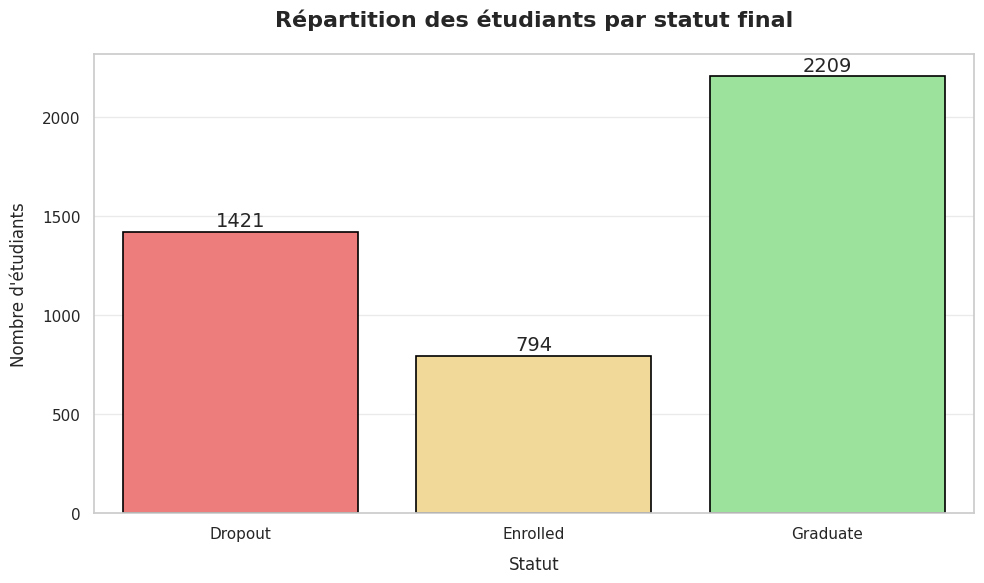

In [89]:
couleurs = {"Dropout": "#FF6B6B", "Enrolled": "#FFE08A", "Graduate": "#90EE90", "Boursier": "#90EE90", "Non-boursier": "#FF6B6B"}

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=data_propre,
    x='Target',
    hue='Target',
    palette=couleurs,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)
plt.title("Répartition des étudiants par statut final", fontsize=16, pad=20, weight='bold')
plt.xlabel("Statut", fontsize=12, labelpad=10)
plt.ylabel("Nombre d'étudiants", fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)

ax.grid(axis='y', alpha=0.4)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=14
    )
plt.tight_layout()
plt.show()


On note ainsi que les trois catégories de notre outcome ne sont pas pas présentes dans les mêmes proportions dans ce dataset. Si une majorité des élèves sont diplômés à la fin de l'année, un tiers des élèves abandonne les études durant l'année. Pour la dernière catégorie, cela représente les élèves qui n'ont pas validé dans le temps réglementaire, ils sont donc encore inscrits pour finir leur cursus. Cela représente un peu moins de 18% des élèves.

In [90]:
cross_tab.describe()

Scholarship holder,Boursier,Non-Boursier
count,13.000000,13.000000
mean,0.189047,0.810953
std,0.113686,0.113686
min,0.043796,0.625551
25%,0.083333,0.757170
50%,0.210526,0.789474
75%,0.242830,0.916667
max,0.374449,0.956204


<Figure size 1200x800 with 0 Axes>

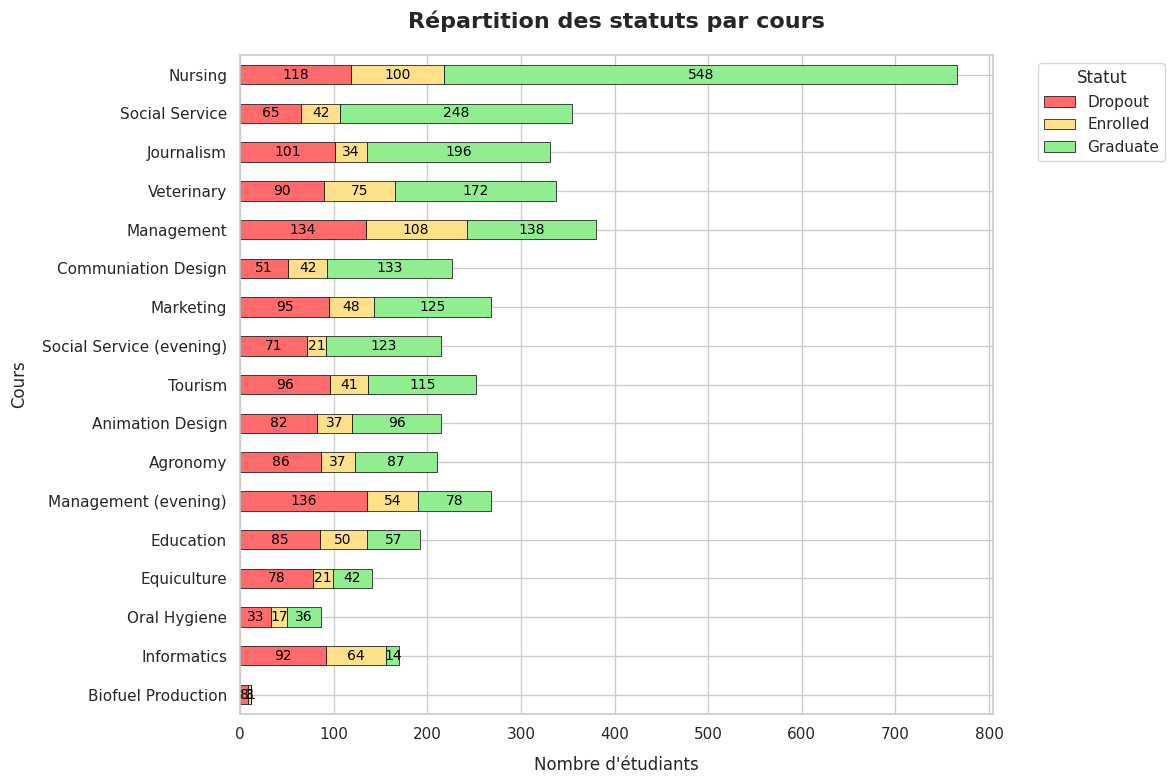

In [91]:
# Préparation des données : comptage des occurrences par cours et par statut
cross_tab = pd.crosstab(data_propre['Course'], data_propre['Target'])
cross_tab = cross_tab.sort_values(by = 'Graduate')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(12, 8))
ax = cross_tab.plot(kind='barh', stacked=True, color=[couleurs['Dropout'], couleurs['Enrolled'], couleurs['Graduate']], edgecolor='black', linewidth=0.5)

plt.title("Répartition des statuts par cours", fontsize=16, pad=20, weight='bold')
plt.xlabel("Nombre d'étudiants", fontsize=12, labelpad=10)
plt.ylabel("Cours", fontsize=12, labelpad=10)

plt.legend(title='Statut', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d', padding=0, fontsize=10, color='black')

plt.tight_layout()
plt.show()


On note ici que quelque soit les études, certains élèves les ont réussi, d'autres ont échoué, et d'autres sont encore en cours d'études.

En revanche, certaines études semblent plus "simples" que d'autres. Par exemple, les études d'infirmier possède un taux de réussite bien plus élevé que les études d'informatique (72% de diplômés contre 8% pour les études d'informatique)

De plus, il est important de noter que les effectifs sont très hétérogènes entre les différentes études dans notre échantillon. Les études d'infirmier comptabilisent presque 800 étudiants, alors que les études maxillo-faciale ne comptent que 86 étudiants.

<Figure size 1200x800 with 0 Axes>

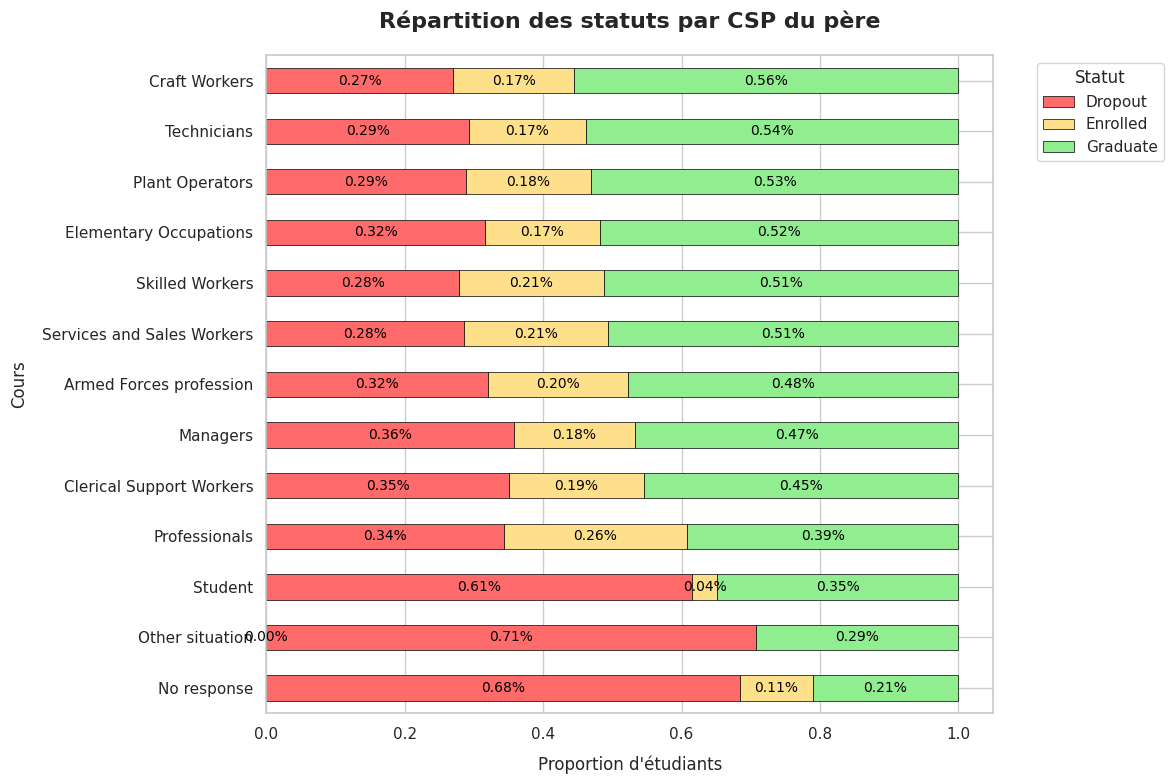

In [92]:
cross_tab = pd.crosstab(data_propre['Father_occupation_sector'], data_propre['Target'])
cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)
cross_tab = cross_tab.sort_values(by = 'Graduate')



sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(12, 8))
ax = cross_tab.plot(kind='barh', stacked=True, color=[couleurs['Dropout'], couleurs['Enrolled'], couleurs['Graduate']], edgecolor='black', linewidth=0.5)

plt.title("Répartition des statuts par CSP du père", fontsize=16, pad=20, weight='bold')
plt.xlabel("Proportion d'étudiants", fontsize=12, labelpad=10)
plt.ylabel("Cours", fontsize=12, labelpad=10)

plt.legend(title='Statut', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.2f%%', padding=0, fontsize=10, color='black')

plt.tight_layout()
plt.show()

On observe ci-dessus la proportion de réussite et d'abandon selon la classe socio-professionnelle du père. Il apparaît que les élèves ayant un père toujours en étude ont en majorité abandonné les études (61%). Ce pourcentage est le double par rapport aux autres CSP du père, où la proportion d'abandon est d'environ 31%.

Ce qui est surprenant, c'est de constater que, quelque soit la profession du père, les taux d'abandon sont sensiblement identiques, alors même que l'on pourrait s'attendre à avoir des taux plus faibles pour les étudiants ayant des parents qualifiés. La réalité de nos données penche plutôt dans le sens contraire : si le taux d'abandon est de 36% pour les fils et filles de cadres, cette proportion descend autour de 28% pour les employés moins qualifiés et les ouvriers.

#### Regardons maintenant les différences entre les étudiants boursiers et les non-boursiers

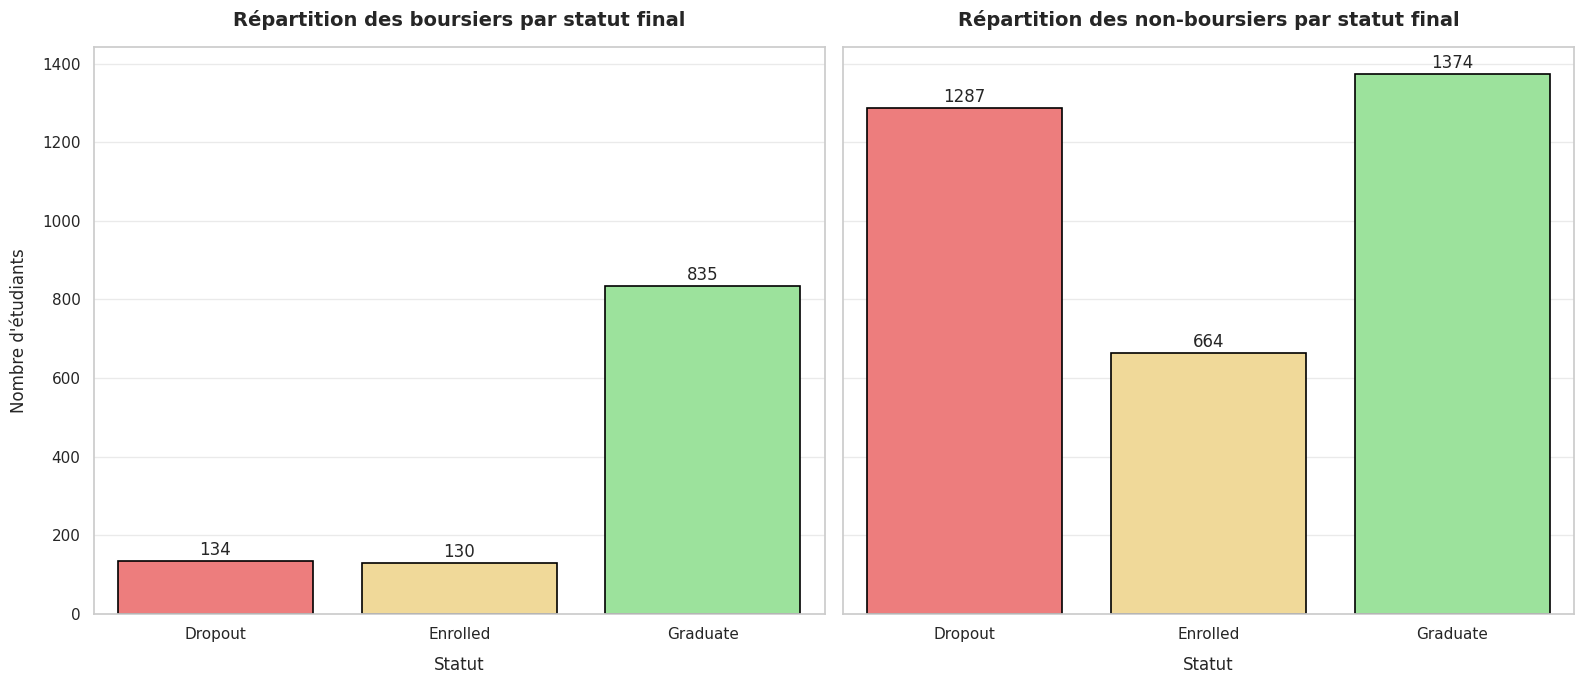

In [93]:
couleurs = {"Dropout": "#FF6B6B", "Enrolled": "#FFE08A", "Graduate": "#90EE90", "Boursier": "#90EE90", "Non-boursier": "#FF6B6B"}


data_boursiers = data_propre[data_propre['Scholarship holder'] == 'Boursier']
data_non_boursiers = data_propre[data_propre['Scholarship holder'] == 'Non-Boursier']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set_theme(style="whitegrid")

sns.countplot(
    data=data_boursiers,
    x='Target',
    hue='Target',
    palette=couleurs,
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    ax=axes[0]
)
axes[0].set_title("Répartition des boursiers par statut final", fontsize=14, pad=15, weight='bold')
axes[0].set_xlabel("Statut", fontsize=12, labelpad=10)
axes[0].set_ylabel("Nombre d'étudiants", fontsize=12, labelpad=10)
axes[0].tick_params(axis='x', rotation=0, labelsize=11)
axes[0].grid(axis='y', alpha=0.4)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=12
    )

sns.countplot(
    data=data_non_boursiers,
    x='Target',
    hue='Target',
    palette=couleurs,
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    ax=axes[1]
)
axes[1].set_title("Répartition des non-boursiers par statut final", fontsize=14, pad=15, weight='bold')
axes[1].set_xlabel("Statut", fontsize=12, labelpad=10)
axes[1].set_ylabel("")  
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].grid(axis='y', alpha=0.4)

for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=12
    )

plt.tight_layout()
plt.show()

Le taux d'abandon est largement plus haut pour les étudiants non-boursiers que pour les boursiers. Mais ici, il n'y a rien de causal, on ne peut pas conclure directement de l'effet d'avoir une bourse sur le décrochage scolaire. En effet, comme nous allons le voir, les étudiants boursiers et non-boursiers n'ont pas du tout les mêmes caractéristiques ! (Nous ne sommes en aucun cas dans un contexte de RCT où la bourse aurait été attribué aléatoirement au sein de la population)

<Figure size 1200x800 with 0 Axes>

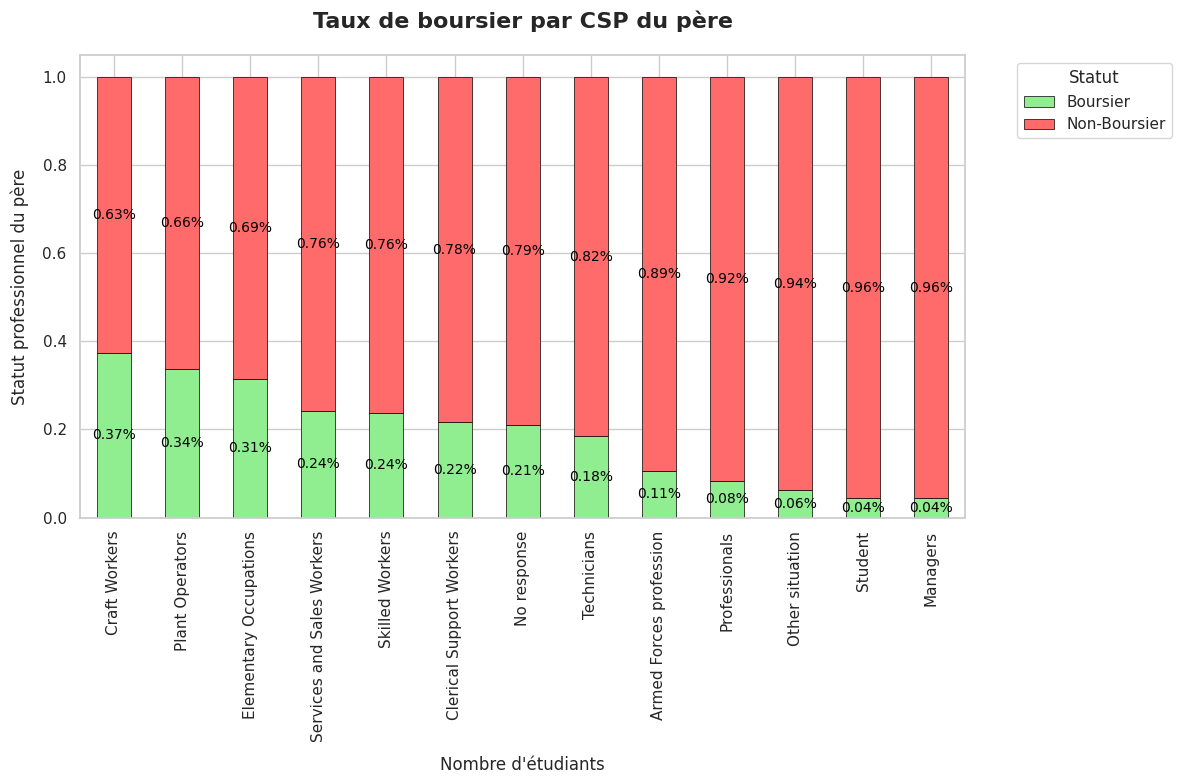

In [94]:
cross_tab = pd.crosstab(data_propre['Father_occupation_sector'], data_propre['Scholarship holder'])
cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)
cross_tab = cross_tab.sort_values(by = 'Non-Boursier')



sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(12, 8))
ax = cross_tab.plot(kind='bar', stacked=True, color=[couleurs['Boursier'], couleurs['Non-boursier']], edgecolor='black', linewidth=0.5)

plt.title("Taux de boursier par CSP du père", fontsize=16, pad=20, weight='bold')
plt.xlabel("Nombre d'étudiants", fontsize=12, labelpad=10)
plt.ylabel("Statut professionnel du père", fontsize=12, labelpad=10)

plt.legend(title='Statut', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.2f%%', padding=0, fontsize=10, color='black')

plt.tight_layout()
plt.show()

En toute logique, les boursiers ont des parents moins aisés que les autres, qui sont donc surreprésentés dans les CSP les moins qualifiés

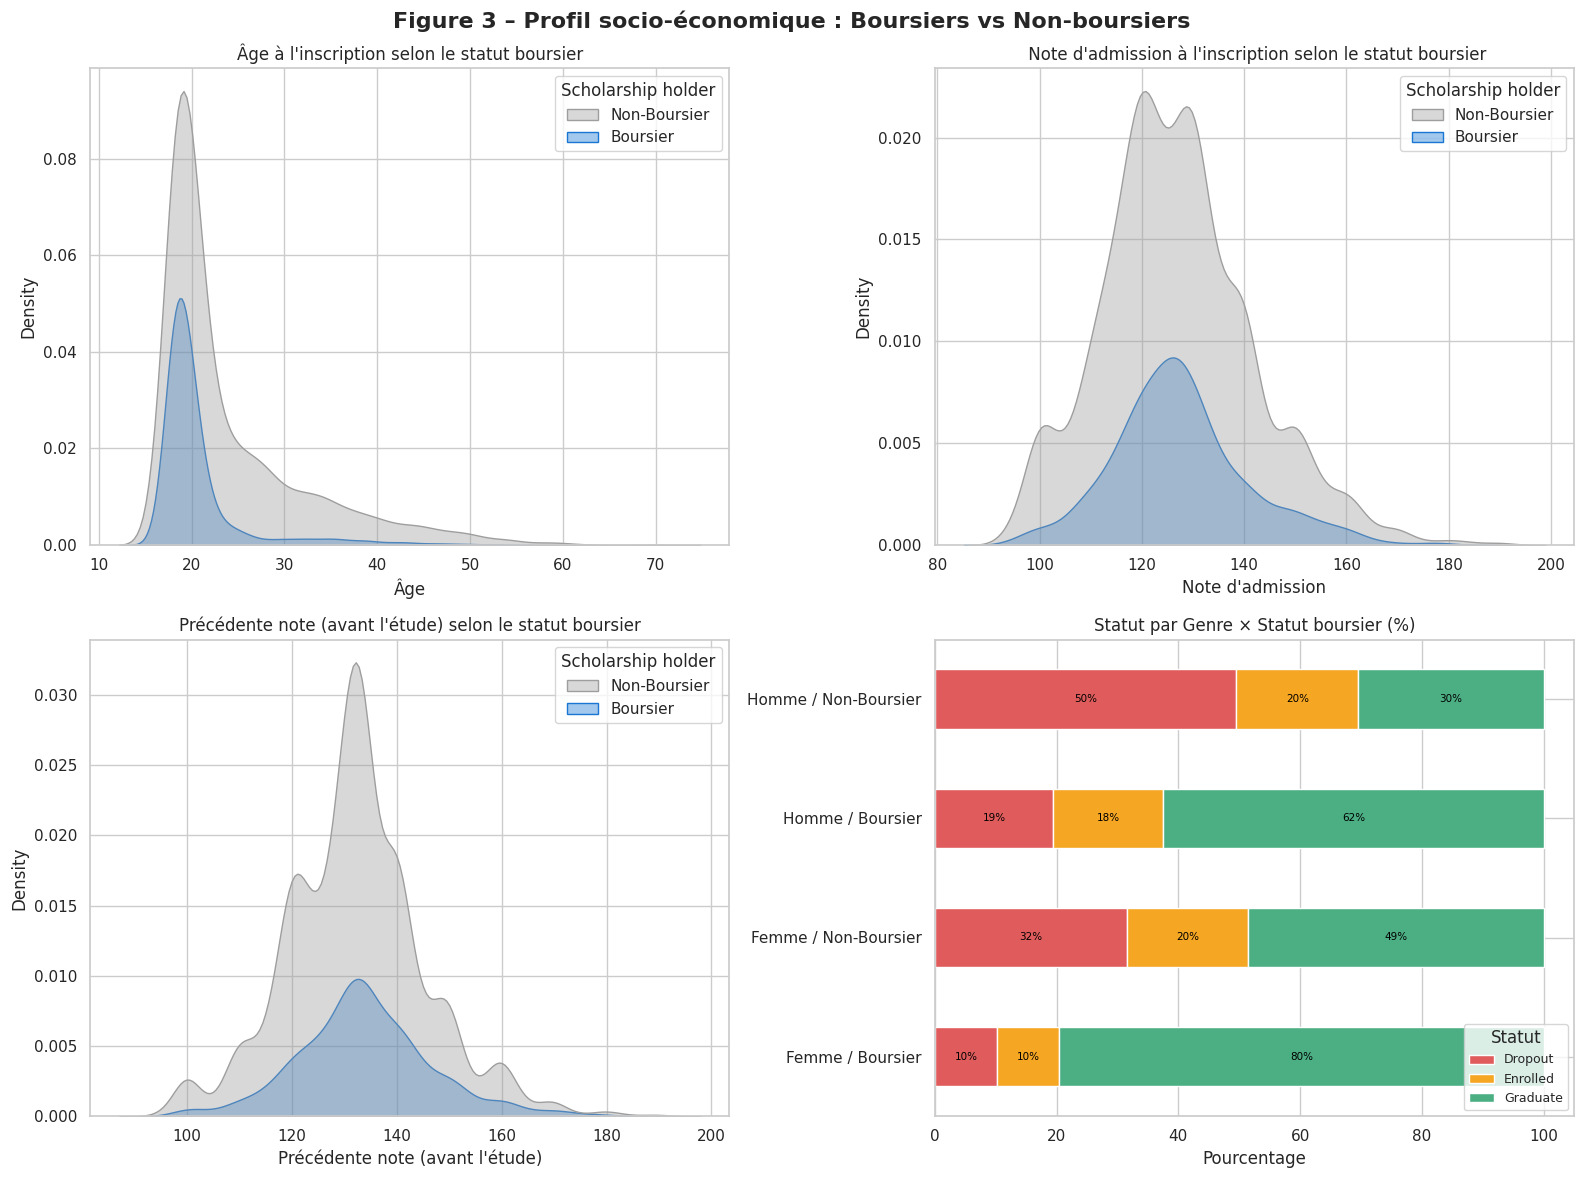

In [95]:

TARGET_ORDER   = ['Dropout', 'Enrolled', 'Graduate']
PALETTE_TARGET = {'Dropout': '#e05c5c', 'Enrolled': '#f5a623', 'Graduate': '#4caf84'}
PALETTE_BOURSE = {"Non-Boursier": '#9e9e9e', "Boursier": '#1976D2'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Figure 3 – Profil socio-économique : Boursiers vs Non-boursiers", fontsize=16, fontweight='bold')

# 3A – Distribution de l'âge
sns.kdeplot(data=data_propre, x='Age at enrollment', hue='Scholarship holder',
            fill=True, alpha=0.4, palette=PALETTE_BOURSE, ax=axes[0, 0])
axes[0, 0].set_title("Âge à l'inscription selon le statut boursier")
axes[0, 0].set_xlabel("Âge")


# 3B – Distribution de la note
sns.kdeplot(data=data_propre, x='Admission grade', hue='Scholarship holder',
            fill=True, alpha=0.4, palette=PALETTE_BOURSE, ax=axes[0, 1])
axes[0, 1].set_title(" Note d'admission à l'inscription selon le statut boursier")
axes[0, 1].set_xlabel("Note d'admission")


# 3C – Distribution de la note avant l'étude
sns.kdeplot(data=data_propre, x='Previous qualification (grade)', hue='Scholarship holder',
            fill=True, alpha=0.4, palette=PALETTE_BOURSE, ax=axes[1, 0])
axes[1, 0].set_title("Précédente note (avant l'étude) selon le statut boursier")
axes[1, 0].set_xlabel("Précédente note (avant l'étude)")


# 3D – Genre × Bourse × Target
gender_cross = pd.crosstab([data_propre['Gender'], data_propre['Scholarship holder']], data_propre['Target'], normalize='index') * 100
gender_cross = gender_cross.reindex(columns=TARGET_ORDER)
labels = ['Femme / Boursier', 'Femme / Non-Boursier', 'Homme / Boursier', 'Homme / Non-Boursier']
gender_cross.index = labels
gender_cross.plot(kind='barh', stacked=True, ax=axes[1, 1],
                  color=[PALETTE_TARGET[t] for t in TARGET_ORDER])
axes[1, 1].set_title("Statut par Genre × Statut boursier (%)")
axes[1, 1].set_xlabel("Pourcentage")
axes[1, 1].legend(title='Statut', loc='lower right', fontsize=9)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.0f%%', label_type='center', fontsize=7.5, color='black')

plt.tight_layout()
plt.show()

## Modèle Double Post-Lasso

Comme nous l'avons vu, faire une simple régression ne permet pas d'estimer l'effet d'une bourse sur l'échec scolaire. En effet, il y a aussi une endogénéité car nous n'observons pas toutes les variables.

Ainsi, une première technique que nous développons ici est celle du Double Post-Lasso.

Dans un premier temps, on régresse Y (la variable binaire de dropout ou non) sur les co-variables avec une régression Lasso pour sélectionner les variables pertinentes. Ensuite, on fait un OLS de Y sur les variables pertinentes.

Dans un second temps, on fait le même procédé pour D (variable binaire indiquant le fait d'avoir une bourse).

Dans un dernier temps, on régresse les résidus de Y sur ceux de D

In [141]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

data_propre_copy = data_propre.copy()

variables_categorielles = ["Displaced","Educational special needs","Debtor","Tuition fees up to date","Daytime/evening attendance","Gender","International",'Application mode', 'Course', 'Father\'s qualification', 'Mother\'s qualification',"Marital Status","Nacionality","Previous qualification","Father_occupation_sector","Mother_occupation_sector"]
data_dummies = pd.get_dummies(data_propre_copy, columns=variables_categorielles, drop_first=True)

# Variables de contrôle (X), traitement (D), outcome (Y)
X = data_dummies.drop(columns=['Target', 'Scholarship holder'])

X = sm.add_constant(X)

D = (data_dummies['Scholarship holder'] == 'Boursier').astype(int)
Y = (data_dummies['Target'] == 'Dropout').astype(int)

variables_numeriques = ['Application order', 'Previous qualification (grade)', 'Admission grade',"Unemployment rate","Inflation rate","GDP"]
scaler = StandardScaler()
X[variables_numeriques] = scaler.fit_transform(X[variables_numeriques])
X = X.applymap(lambda x: int(x) if isinstance(x, bool) else x)

/tmp/ipykernel_63787/2300074739.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(lambda x: int(x) if isinstance(x, bool) else x)


### Régression Post-Lasso sur Y

In [142]:
# Régression Lasso avec validation croisée de Y sur X
lasso_Y = LassoCV(cv=5, random_state=42).fit(X, Y)

lasso_Y_coef = pd.Series(lasso_Y.coef_, index=X.columns)
print("Coefficients Lasso :\n", lasso_Y_coef)

variables_selectionnees = lasso_Y_coef[lasso_Y_coef != 0].index.tolist()
print("\nFeatures sélectionnées :", variables_selectionnees)


Coefficients Lasso :
 const                                                  0.000000
Application order                                      0.011918
Previous qualification (grade)                         0.007612
Admission grade                                       -0.037110
Age at enrollment                                      0.005787
                                                         ...   
Mother_occupation_sector_Professionals                 0.000000
Mother_occupation_sector_Services and Sales Workers   -0.000000
Mother_occupation_sector_Skilled Workers              -0.000000
Mother_occupation_sector_Student                       0.193729
Mother_occupation_sector_Technicians                  -0.036496
Length: 174, dtype: float64

Features sélectionnées : ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP', 'Displaced_1', 'Debtor_1', 'Tuition fees up to date_1', 'Gender_Male', 'Intern

In [143]:
X_selected = X[variables_selectionnees]
X_selected = sm.add_constant(X_selected, has_constant='add')


logit_model_Y = sm.Logit(Y, X_selected).fit(disp=0)


print(logit_model_Y.summary())


                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4362
Method:                           MLE   Df Model:                           61
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.2822
Time:                        16:52:54   Log-Likelihood:                -1993.5
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                2.081e-287
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                                   0.3185      0.286      1.115      0.265      -0.241       0.878
Applicat

In [144]:
Y_pred = logit_model_Y.predict(X_selected)

residus_Y = Y - Y_pred



### Régression Post-Lasso sur D

In [145]:
lasso_D = LassoCV(cv=5, random_state=42).fit(X, D)

lasso_D_coef = pd.Series(lasso_D.coef_, index=X.columns)
print("Coefficients Lasso :\n", lasso_D_coef)

variables_selectionnees = lasso_D_coef[lasso_D_coef != 0].index.tolist()
print("\nFeatures sélectionnées :", variables_selectionnees)

Coefficients Lasso :
 const                                                  0.000000
Application order                                     -0.000694
Previous qualification (grade)                         0.016328
Admission grade                                        0.005629
Age at enrollment                                     -0.006201
                                                         ...   
Mother_occupation_sector_Professionals                -0.044306
Mother_occupation_sector_Services and Sales Workers    0.034322
Mother_occupation_sector_Skilled Workers               0.019649
Mother_occupation_sector_Student                      -0.000000
Mother_occupation_sector_Technicians                  -0.000000
Length: 174, dtype: float64

Features sélectionnées : ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP', 'Displaced_1', 'Debtor_1', 'Tuition fees up to date_1', 'Gender_Male', 'Intern

In [146]:
X_selected = X[variables_selectionnees]
X_selected = sm.add_constant(X_selected, has_constant='add')


logit_model_D = sm.Logit(D, X_selected).fit(disp=0)


print(logit_model_D.summary())


                           Logit Regression Results                           
Dep. Variable:     Scholarship holder   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4352
Method:                           MLE   Df Model:                           71
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.1954
Time:                        16:54:05   Log-Likelihood:                -1995.5
converged:                      False   LL-Null:                       -2480.1
Covariance Type:            nonrobust   LLR p-value:                9.943e-158
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                                  -1.7146      0.421     -4.073      0.000      -2.540      -0.889
Applicat

/opt/python/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [147]:
D_pred = logit_model_D.predict(X_selected)

residus_D = D - D_pred

### Régression des résidus

In [ ]:
# Régression des résidus de Y sur les résidus de D
post_lasso_model = sm.OLS(residus_Y, sm.add_constant(residus_D)).fit(cov_type='HC3')

print(post_lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     96.04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.90e-22
Time:                        16:56:35   Log-Likelihood:                -1959.3
No. Observations:                4424   AIC:                             3923.
Df Residuals:                    4422   BIC:                             3935.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.026e-16      0.006  -1.24e-13      1.0